In [ ]:
import os
import glob
import re

import pandas as pd
import matplotlib.pyplot as plt


def plot_and_average_csv(prefix, sub_title, xscale, total_title, xlabel, ylabel, folder="."):

    pattern = os.path.join(folder, f"{prefix}*.csv")
    files = sorted(glob.glob(pattern))

    num_pattern = re.compile(re.escape(prefix) + r"(\d+)\.csv$")

    all_dfs = []

    if type(xscale) == int:
        xscale = [xscale] * len(files)
    elif type(xscale) == str:
        if len(files) != len(xscale):
            print(f"doesn't match size, got {len(files)} files")
            return
    else:
        print("unrecognized xscale")
        return

    for f, scale in zip(files, xscale):
        basename = os.path.basename(f)
        m = num_pattern.search(basename)
        if not m:
            continue

        suffix = m.group(1)
        df = pd.read_csv(f, header=None)

        x = pd.to_numeric(df.iloc[:, 0], errors="coerce")
        y = pd.to_numeric(df.iloc[:, 1], errors="coerce")

        mask = (~x.isna()) & (~y.isna())
        x = x[mask] * scale
        y = y[mask]


        plt.figure()
        plt.plot(x, y)
        plt.title(f"{sub_title}{suffix}")
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.grid(True)

        all_dfs.append(pd.DataFrame({"x": x, "y": y}))

    if not all_dfs:
        print("No found csv fill, example:", f"{prefix}1.csv, {prefix}2.csv ...")
        return

    all_data = pd.concat(all_dfs, axis=0)
    mean_df = all_data.groupby("x", as_index=False)["y"].mean()

    plt.figure()
    plt.plot(mean_df["x"], mean_df["y"])
    plt.title(total_title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    # plt.savefig(os.path.join(folder, f"{prefix}_mean.png"), dpi=300)

    mean_csv_path = os.path.join(folder, f"{prefix}_mean.csv")
    mean_df.to_csv(mean_csv_path, index=False)
    print(f"Average saved: {mean_csv_path}")

In [47]:
def plot_multiple_csv(files, legends, xscale, xlabel="x", ylabel="y", title="Combined Plot", folder = "."):
    """
    files:   list of CSV file paths
    legends: list of legend names, same length as `files`
    """

    if len(files) != len(legends) or len(files) != len(xscale):
        raise ValueError("files, scales and legends must have the same length")

    plt.figure()

    for f, legend, scale in zip(files, legends, xscale):
        # read CSV (first two columns)
        pattern = os.path.join(folder, f"{f}.csv")
        df = pd.read_csv(pattern, header=None)

        # force numeric and drop invalid
        x = pd.to_numeric(df.iloc[:, 0], errors="coerce")
        y = pd.to_numeric(df.iloc[:, 1], errors="coerce")
        valid = (~x.isna()) & (~y.isna())
        x = x[valid] * scale
        y = y[valid]

        plt.plot(x, y, label=legend)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [44]:
files = ["brctmazereg_mean", "brctmazeregtrain_mean"]
legends = ["Test","Train"]
xlabel = "training episodes (for agents)"
ylabel = "R^2"
title = "Training (decoding matrix W) vs Testing R^2 for TMaze with BRC"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = [20, 20]

In [54]:
files = ["brctmazereg_mean", "brctmazereward"]
legends = ["R^2 of decoding","Value"]
xlabel = "training episodes (for agents)"
ylabel = "R^2/value function"
title = "R^2 and learned value function across episodes of training for TMaze with BRC"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = [5, 10]

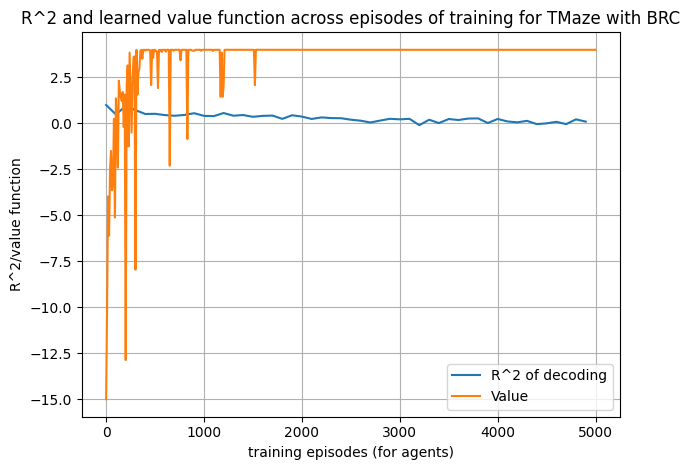

In [55]:
plot_multiple_csv(files, legends, xscale, xlabel, ylabel, title, folder)

In [19]:
prefix = "brctmazereg"
sub_title = "Test R^2 for linear decoding hidden states in TMaze with BRC"
total_title = "Average test R^2 for linear decoding hidden states in TMaze with BRC"
xlabel = "training steps"
ylabel = "R^2"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = 20

In [23]:
prefix = "brctmazeregtrain"
sub_title = "Training R^2 for linear decoding hidden states in TMaze with BRC"
total_title = "Average training R^2 for linear decoding hidden states in TMaze with BRC"
xlabel = "training steps"
ylabel = "R^2"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = 20

In [40]:
prefix = "grutmazereg"
sub_title = "Test R^2 for linear decoding hidden states in TMaze with GRU"
total_title = "Average test R^2 for linear decoding hidden states in TMaze with GRU"
xlabel = "training steps"
ylabel = "R^2"
folder = r"D:\Life\University\项目\Mate\gru-multiple run"
xscale = 100

Average saved: D:\Life\University\项目\Mate\gru-multiple run\grutmazereg_mean.csv


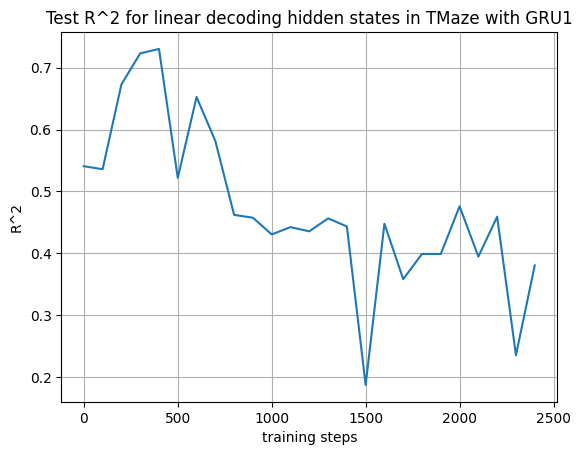

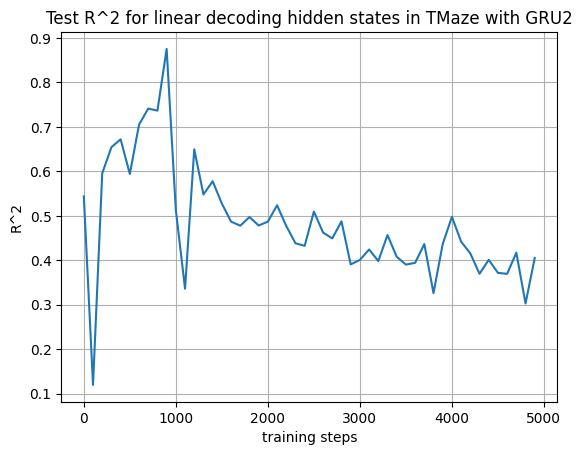

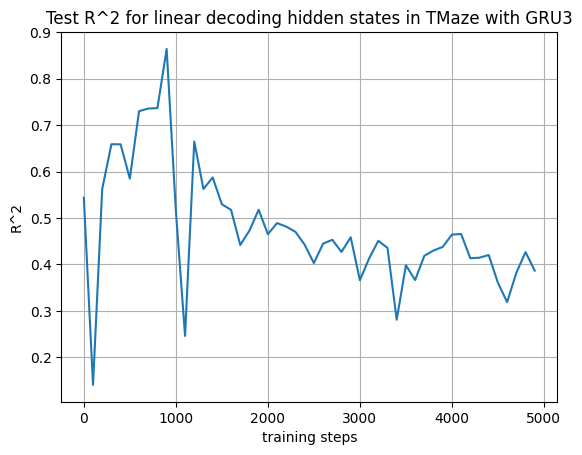

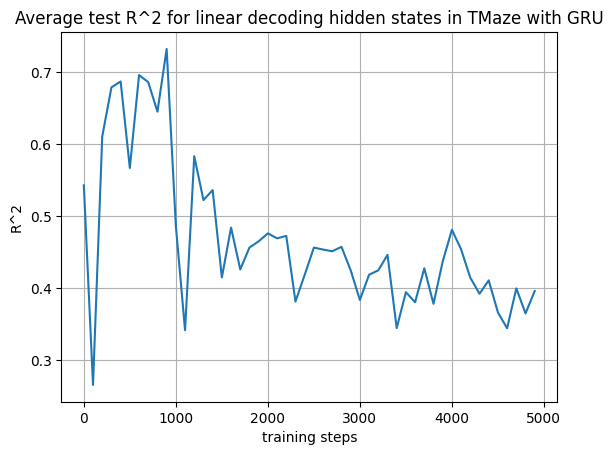

In [41]:
plot_and_average_csv(prefix, sub_title, total_title, xlabel, ylabel, folder, xscale)